In [ ]:
import numpy as np
import torch
import pandas as pd
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
import os
import sklearn
import io
import scipy as sp
from sklearn import linear_model
import scipy.stats as st
import seaborn as sns
from sklearn.utils import resample





mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Times New Roman'

############################################################################################################
df = pd.read_csv('/data/real_data_AD_MRI.csv')

df = df.sort_values(by=['SampleSize'])
sample_space = np.array(df['SampleSize'])
reported_accuracy = np.array(df['Accuracy'])

sns.set_style("white")
sns.set_style("ticks")
fig = plt.figure(figsize=(3.42,2.36), dpi = 200)

ax = plt.axes()

ax.semilogx(sample_space,reported_accuracy,'o',markersize=2,label = 'Control vs. AD')
ax.set_xscale('log')

ax.tick_params(axis='y',which='major',direction='out',length=1,width=0.5,color='black',pad=2,labelsize=6,labelcolor='black')
ax.tick_params(axis='x',which='minor',direction='out',length=1,width=0.5,color='black',labelcolor='black')
ax.tick_params(axis='x',which='major',direction='out',length=2,width=1,color='black',pad=2,labelsize=6,labelcolor='black')

ax.set_xlim(10,1000)

plt.xlabel('Sample size',fontsize = 6)
plt.ylabel('Reported accuracy',fontsize = 6)
plt.legend(loc='upper right',fontsize = 6)
ax.grid(axis='x', color='0.9')
ax.grid(axis='y', color='0.9')

plt.show()
############################################################################################################


In [ ]:
sample_space1 = torch.linspace(10,100, steps = 10)
sample_space2 = torch.linspace(100,1000, steps = 10)
sample_space3 = torch.linspace(1000.0,10000.0, steps = 10)
sample_space_plot = torch.cat((sample_space1,sample_space2,sample_space3),dim = 0)
sample_space_plot = sample_space_plot.unique()
#sample_space_plot = torch.cat((sample_space1,sample_space2),dim = 0)
sample_space_plot_size = sample_space_plot.shape[0]

In [ ]:
# Test sample space
from sklearn.linear_model import QuantileRegressor
from sklearn.utils.fixes import parse_version, sp_version

solver = "highs"
lower_quantile = 0.10
upper_quantile = 0.90
quantiles = [lower_quantile,0.5,upper_quantile]
predictions = {}
predictions_interpolate = {}
out_bounds_predictions = np.zeros_like(reported_accuracy, dtype=np.bool_)
out_bounds_predictions_below = np.zeros_like(reported_accuracy, dtype=np.bool_)

Sample_space = sample_space.reshape(-1, 1)
Reported_accuracy = reported_accuracy.reshape(-1, 1)
Sample_space_plot = sample_space_plot.reshape(-1,1)

#sample_space = torch.cat((sample_space1,sample_space2,sample_space3,sample_space4),dim = 0)

for quantile in quantiles:
    qr = QuantileRegressor(quantile=quantile, alpha=0.5,solver=solver)
    model = qr.fit(Sample_space, Reported_accuracy.ravel())
    y_pred = model.predict(Sample_space)
    predictions[quantile] = y_pred
    predictions_interpolate[quantile] = model.predict(Sample_space_plot)

    if quantile == min(quantiles):
        out_bounds_predictions = np.logical_or(
            out_bounds_predictions, y_pred >= reported_accuracy
        )
############################################################################################



sns.set_style("white")
sns.set_style("ticks")
fig = plt.figure(figsize=(3.42,2.36), dpi = 200)
ax = plt.axes()


for quantile, y_pred in predictions.items():
    plt.semilogx(Sample_space, y_pred, label=f"Quantile: {quantile}")


plt.scatter(
    sample_space[out_bounds_predictions],
    reported_accuracy[out_bounds_predictions],
    color="red",
    marker="v",
    s = 4,
    alpha=0.5,
    label="Outside interval",
)
plt.scatter(
    sample_space[~out_bounds_predictions],
    reported_accuracy[~out_bounds_predictions],
    color="blue",
    alpha=0.5,
    s=4,
    label="Inside interval",
)
ax.tick_params(axis='y',which='major',direction='out',length=1,width=0.5,color='black',pad=2,labelsize=6,labelcolor='black')
ax.tick_params(axis='x',which='minor',direction='out',length=1,width=0.5,color='black',labelcolor='black')
ax.tick_params(axis='x',which='major',direction='out',length=2,width=1,color='black',pad=2,labelsize=6,labelcolor='black')
ax.set_yticks([0.5,0.6, 0.7, 0.8, 0.9, 1.0])
#ax2.set_xticks([10,100],['10','100'])
ax.set_ylim(0.45,1.05)
ax.set_xlim(10,1000)

plt.xlabel('Sample size - N',fontsize = 6)
plt.ylabel('Accuracy',fontsize = 6)
plt.legend(loc='upper right',fontsize = 6)
ax.grid(axis='x', color='0.9')
ax.grid(axis='y', color='0.9')


plt.savefig('/results/quantile_reg.png', format='png',dpi = 200)
plt.show()

# keep outliers for future plots
N_dataset_outliers = sample_space
reported_acc_outliers = reported_accuracy

N_dataset = sample_space[~out_bounds_predictions]
experiment_bias = reported_accuracy[~out_bounds_predictions]

data_outlier_removed = {'SampleSize': N_dataset, 'Accuracy': experiment_bias}
df3 = pd.DataFrame(data=data_outlier_removed)



In [ ]:
# Test sample space
from sklearn.linear_model import QuantileRegressor
lower_quantile = 0.10
upper_quantile = 0.90
quantiles = [lower_quantile,0.5,upper_quantile]
predictions = {}
predictions_interpolate = {}
out_bounds_predictions = np.zeros_like(reported_accuracy, dtype=np.bool_)
out_bounds_predictions_below = np.zeros_like(reported_accuracy, dtype=np.bool_)

Sample_space = sample_space.reshape(-1, 1)
Reported_accuracy = reported_accuracy.reshape(-1, 1)
Sample_space_plot = sample_space_plot.reshape(-1,1)

#sample_space = torch.cat((sample_space1,sample_space2,sample_space3,sample_space4),dim = 0)

for quantile in quantiles:
    qr = QuantileRegressor(quantile=quantile, alpha= 0.5,solver = solver)
    model = qr.fit(Sample_space, Reported_accuracy.ravel())
    y_pred = model.predict(Sample_space)
    predictions[quantile] = y_pred
    predictions_interpolate[quantile] = model.predict(Sample_space_plot)

######################Remove outliers from below only###################################

    if quantile == min(quantiles):
        out_bounds_predictions = np.logical_or(
            out_bounds_predictions, y_pred >= reported_accuracy
        )
############################################################################################

N_dataset_outliers = sample_space
reported_acc_outliers = reported_accuracy

N_dataset = sample_space[~out_bounds_predictions]
experiment_bias = reported_accuracy[~out_bounds_predictions]



def estimate_threshold(sample_used,accuracy_used):
  size_Sample_space = sample_used.shape[0]
  Sample_space_unique = np.unique(sample_used)
  size_Sample_space_unique = Sample_space_unique.shape[0]

  threshold_estimated = np.zeros(size_Sample_space)
  stride = 1
  old_scale = 100
  for window_start_point in range(0,size_Sample_space_unique,1):
    if (window_start_point == size_Sample_space_unique - 1):
      window = window_start_point
    else:
      window = np.linspace(window_start_point,window_start_point+stride-1,stride).astype(int)

    window_on_samples = Sample_space_unique[window]
    Sample_space_indexes = np.where(np.isin(sample_used,window_on_samples))[0]
    Reported_accuracy_quant = accuracy_used[Sample_space_indexes]
    new_scale = np.min(Reported_accuracy_quant)
    final_scale = np.minimum(old_scale,new_scale)
    threshold_estimated[Sample_space_indexes] = final_scale
    old_scale = final_scale

  y_L = threshold_estimated
  return y_L

def estimate_threshold_evaluation(y_L,sample_used,N_dataset_eval):
  sample_used_eval,sample_used_rank = np.unique(sample_used,return_index=True)
  y_L_eval = y_L[sample_used_rank]

  N_samples_eval = N_dataset_eval.size

  size_Sample_space_unique = sample_used_eval.shape[0]

  threshold_eval_estimated = np.zeros(N_samples_eval)
  locations = np.where(np.isin(N_dataset_eval,sample_used_eval))[0]
  threshold_eval_estimated[locations] = y_L_eval

  for i in range(len(threshold_eval_estimated)):

    if threshold_eval_estimated[i] == 0:
      left = i - 1
      right = i + 1

      while left >= 0 and threshold_eval_estimated[left] == 0:
        left -= 1

      while right < len(threshold_eval_estimated) and threshold_eval_estimated[right] == 0:
        right += 1

      threshold_eval_estimated[i] = threshold_eval_estimated[left] if left >= 0 else threshold_eval_estimated[right]


  y_L_eval = threshold_eval_estimated

  return y_L_eval





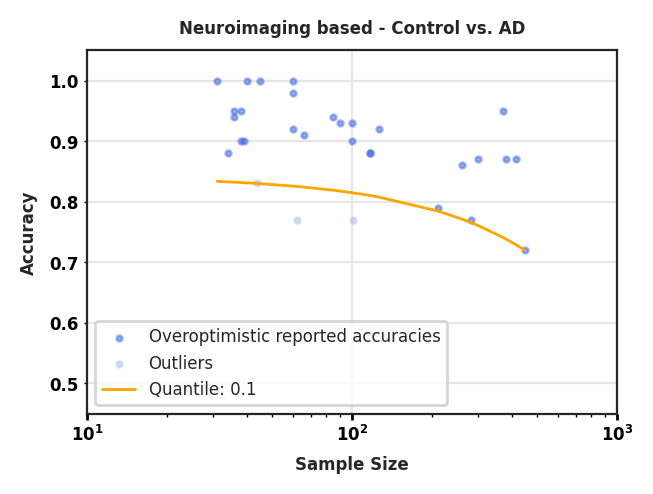

In [ ]:
from matplotlib.legend_handler import HandlerTuple
sns.set_style("white")
sns.set_style("ticks")
fig = plt.figure(figsize=(3.42,2.36), dpi = 200)
ax3 = plt.axes()

scatter1 = plt.scatter(
    sample_space[~out_bounds_predictions],
    reported_accuracy[~out_bounds_predictions],
    color="royalblue",
    s = 4,
    alpha=0.5,
    label="Overoptimistic reported accuracies",
)
scatter2 = plt.scatter(
    sample_space[out_bounds_predictions],
    reported_accuracy[out_bounds_predictions],
    color="lightsteelblue",
    alpha=0.5,
    s=4,
    label="Outliers",)
quantile = lower_quantile

ax3.plot(Sample_space,predictions[lower_quantile],color = 'orange',linewidth=1, label= 'Quantile: 0.1')



ax3.set_xscale('log')

ax3.tick_params(axis='y',which='major',direction='out',length=1,width=0.5,color='black',pad=2,labelsize=6,labelcolor='black')
ax3.tick_params(axis='x',which='minor',direction='out',length=1,width=0.5,color='black',labelcolor='black')
ax3.tick_params(axis='x',which='major',direction='out',length=2,width=1,color='black',pad=2,labelsize=6,labelcolor='black')

ax3.set_ylim(0.45,1.05)
ax3.set_xlim(10,1000)
plt.xticks(weight = 'bold')
plt.yticks(weight = 'bold')
plt.xlabel('Sample Size',fontsize = 6, fontweight='bold')
plt.ylabel('Accuracy',fontsize = 6, fontweight='bold')

legend = ax3.legend(fontsize = 6,loc = 'lower left')
#bbox_to_anchor=(1.55, 1.0)
ax3.grid(axis='x', color='0.9')
ax3.grid(axis='y', color='0.9')
plt.title('Neuroimaging based - Control vs. AD',fontsize = 6, fontweight='bold')
plt.savefig('threshold_new.png', format='png',dpi = 200,bbox_inches = 'tight')

plt.show()


df_samplesize = pd.DataFrame(sample_space_plot,columns = ['SampleSize'])
df_threshold = pd.DataFrame(predictions_interpolate[lower_quantile],columns = ['threshold'])


df_threshold = pd.concat([df_samplesize,df_threshold],axis=1).to_csv('threshold_mm_ASD.csv')



In [ ]:
from pymoo.core.problem import ElementwiseProblem

class MyProblem(ElementwiseProblem):

    def __init__(self):
        super().__init__(n_var=5,
                         n_obj=2,
                         n_ieq_constr=0,
                         xl=np.array([0.5,-2,-1,0,0.001]),
                         xu=np.array([1,-0.5,-0.05,1,0.5]))

    def _evaluate(self, x, out, *args, **kwargs):
      mu_unique = x[0] + x[1]*(sample_used_new_unique**x[2]) + x[3]*(sample_used_new_unique**(-0.5))
      zprime = np.sqrt(sample_used_new_unique)*(y_L_used_unique - mu_unique)/x[4]
      if ((1-sp.stats.norm.cdf(zprime,loc = 0,scale = 1)).all() ==False):
        epsilon = 10**-20
      else:
        epsilon = 0
      epsi_prime = (sp.stats.norm.pdf(zprime,loc = 0,scale = 1))/(1-sp.stats.norm.cdf(zprime,loc = 0,scale = 1)+epsilon)

      f1 = sum(((mu_unique + (x[4]/np.sqrt(sample_used_new_unique))* epsi_prime) - mean_used)**2)

      f2 = sum((((x[4]**2)/sample_used_new_unique)*(1 + (zprime*epsi_prime) - epsi_prime) - variance_used)**2)

      out["F"] = [f1,f2]

problem = MyProblem()

In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling

algorithm = NSGA2(
    pop_size=40,
    n_offsprings=10,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)


In [ ]:
### We create 10000 bootstrap samples for computing the confidence intervals. To run the code faster, we can change the n_repeats to 100.

from pymoo.termination import get_termination
termination = get_termination("n_gen", 400)

from pymoo.optimize import minimize
from pymoo.decomposition.asf import ASF


N_samples = N_dataset.size
#beta_grid = Beta_space[beta_final_ind]
N_dataset_eval,N_dataset_rank = np.unique(N_dataset,return_index=True)
N_samples_eval = N_dataset_eval.size
n_repeats = 10000
itr_for_initialization = 1

model_recovered_ML = np.zeros((n_repeats,N_samples_eval))
model_recovered_ML_OF = np.zeros((n_repeats,N_samples_eval))

MLR_estimated = np.zeros((n_repeats,N_samples_eval))
target_acc_vec = np.zeros((n_repeats,1))
alpha_star_vec = np.zeros((n_repeats,1))
beta_star_vec = np.zeros((n_repeats,1))
zeta_star_vec = np.zeros((n_repeats,1))
c1_vec = np.zeros((n_repeats,1))

n_samples_used=len(N_dataset)


def eval_func_complete(target_accuracy,alpha_star,beta_star,zeta_star,c_1_star):

  mu = target_accuracy + alpha_star*(N_dataset_eval**beta_star) + zeta_star*(N_dataset_eval**(-0.5))
  z = np.sqrt(N_dataset_eval)*(y_L_eval - mu)/c_1_star
  if ((1-sp.stats.norm.cdf(z,loc = 0,scale = 1)).all() ==False):
    epsilon = 10**-20
  else:
    epsilon = 0
  return mu + (c_1_star/np.sqrt(N_dataset_eval))* (sp.stats.norm.pdf(z,loc = 0,scale = 1))/(1-sp.stats.norm.cdf(z,loc = 0,scale = 1)+epsilon)

def caluclate_variance(sample_used_new,accuracy_used_new):
  v_sample_used_unique = np.unique(sample_used_new)
  variance_used = []
  mean_used = []
  for N_S in (v_sample_used_unique):
    v_sample_index = np.where(np.isin(sample_used_new,N_S))[0]
    A_temp = []
    A_temp = accuracy_used_new[v_sample_index]
    A_temp = np.array([A_temp])
    variance_cal = np.var(A_temp)
    mean_cal = np.mean(A_temp)
    variance_used.append(variance_cal)
    mean_used.append(mean_cal)
  variance_used = np.array([variance_used])
  mean_used = np.array([mean_used])

  return variance_used.squeeze(),mean_used.squeeze()




prog_bar1 = tqdm(total = n_repeats)
for i in range(n_repeats):
  time.sleep(0.3)
  n_samples_used=len(N_dataset)
  [sample_used,accuracy_used] = resample(N_dataset,experiment_bias,n_samples = len(N_dataset))

  #[sample_used,accuracy_used] = resample(N_dataset,experiment_bias,n_samples = len(N_dataset))

  ########## Mean Acc - Required for Initialization##################
  sorting_index = np.argsort(sample_used)   #argsort sort in ascending order
  sample_used_new = sample_used[sorting_index]
  sample_used_new_unique,unique_samples_indices = np.unique(sample_used_new, return_index=True) #unique sort in ascending order in this case doesn't have any effect
  accuracy_used_new = accuracy_used[sorting_index]
  y_L_used = estimate_threshold(sample_used_new,accuracy_used_new)
  y_L_eval = estimate_threshold_evaluation(y_L_used,sample_used_new,N_dataset_eval)

  sample_used_unique = np.unique(sample_used)

  ##########End of Block - Mean Acc##################
  #y_L_used = estimate_threshold(sample_used_new,accuracy_used_new)
  y_L_used_unique = y_L_used[unique_samples_indices] #This is for variance calculations in the objective function
  #y_L_eval = estimate_threshold_evaluation(y_L_used,sample_used_new,N_dataset_eval)
  variance_used,mean_used = caluclate_variance(sample_used_new,accuracy_used_new)



  res = minimize(problem,
               algorithm,
               termination,
               seed=1,
               save_history=True,
               verbose=False)

  X = res.X
  F = res.F


  approx_ideal = F.min(axis=0)
  approx_nadir = F.max(axis=0)
  nF = (F - approx_ideal) / (approx_nadir - approx_ideal)


  weights = np.array([0.999999, 0.000001])
  decomp = ASF()
  best_answer = decomp.do(nF, 1/weights).argmin()
  X_final = X[best_answer,:]
  target_accuracy = X_final[0]
  alpha_star = X_final[1]
  beta_star = X_final[2]
  zeta_star = X_final[3]
  c_1_star = X_final[4]


  target_acc_vec[i,0] = target_accuracy
  alpha_star_vec[i,0] = alpha_star
  beta_star_vec[i,0] = beta_star
  zeta_star_vec[i,0] = zeta_star
  c1_vec[i,0] = c_1_star

  model_recovered_ML[i,:] = target_accuracy + alpha_star*(N_dataset_eval**beta_star)
  model_recovered_ML_OF[i,:] = target_accuracy + alpha_star*(N_dataset_eval**beta_star)+zeta_star*(N_dataset_eval**(-0.5))

  MLR_estimated[i,:] = eval_func_complete(target_accuracy,alpha_star,beta_star,zeta_star,c_1_star)

  prog_bar1.update(1)
model_recovered_ML = np.where(model_recovered_ML>1,1,model_recovered_ML)
model_recovered_ML_OF = np.where(model_recovered_ML_OF>1,1,model_recovered_ML_OF)
MLR_estimated = np.where(MLR_estimated>1,1,MLR_estimated)

prog_bar1.close()



  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
MLR_temp = MLR_estimated
confidence_bounds_set_MLR = []
for cb in range(N_samples_eval):
  confidence_bounds_MLR = [np.percentile(MLR_temp[:,cb], 2.5),np.percentile(MLR_temp[:,cb], 97.5)]

  confidence_bounds_set_MLR.append(confidence_bounds_MLR)

lb_MLR = np.array(confidence_bounds_set_MLR)[:,0]
ub_MLR = np.array(confidence_bounds_set_MLR)[:,1]

MLR_estimated_avg = np.mean(MLR_estimated,0)


B_temp = model_recovered_ML
confidence_bounds_set_mr = []
for cb in range(N_samples_eval):
  confidence_bounds_mr = [np.percentile(B_temp[:,cb], 2.5),np.percentile(B_temp[:,cb], 97.5)]

  confidence_bounds_set_mr.append(confidence_bounds_mr)
lb_mr = np.array(confidence_bounds_set_mr)[:,0]
ub_mr = np.array(confidence_bounds_set_mr)[:,1]

model_recovered_mr = np.mean(model_recovered_ML,0)
C_temp = model_recovered_ML_OF
confidence_bounds_set_OF = []
for cb in range(N_samples_eval):
  confidence_bounds_OF = [np.percentile(C_temp[:,cb], 2.5),np.percentile(C_temp[:,cb], 97.5)]


  confidence_bounds_set_OF.append(confidence_bounds_OF)
lb_OF = np.array(confidence_bounds_set_OF)[:,0]
ub_OF = np.array(confidence_bounds_set_OF)[:,1]

model_recovered_OF = np.mean(model_recovered_ML_OF,0)

In [ ]:
from matplotlib.legend_handler import HandlerTuple
sns.set_style("white")
sns.set_style("ticks")
fig = plt.figure(figsize=(3.42,2.36), dpi = 200)
ax2 = plt.axes()

scatter1 = plt.scatter(
    sample_space[~out_bounds_predictions],
    reported_accuracy[~out_bounds_predictions],
    color="royalblue",
    s = 4
)
scatter2 = plt.scatter(
    sample_space[out_bounds_predictions],
    reported_accuracy[out_bounds_predictions],
    color="darkorange",
    s=4,
    marker = '^')




pl2, = ax2.plot(N_dataset_eval,MLR_estimated_avg,'-',color = 'royalblue',linewidth=1,markersize=1,label = "Fit to the Mill's ratio")



ax2.fill_between(N_dataset_eval,lb_MLR,ub_MLR,color ='navy',alpha = 0.1)

pl3, = ax2.plot(N_dataset_eval,model_recovered_mr,linestyle = 'dashdot',color = 'red',linewidth=1,markersize=2,label = 'Estimated learning curve')

ax2.fill_between(N_dataset_eval,lb_mr,ub_mr,color = 'tomato',alpha = 0.1)

ax2.set_xscale('log')

ax2.tick_params(axis='y',which='major',direction='out',length=1,width=0.5,color='black',pad=2,labelsize=6,labelcolor='black')
ax2.tick_params(axis='x',which='minor',direction='out',length=1,width=0.5,color='black',labelcolor='black')
ax2.tick_params(axis='x',which='major',direction='out',length=2,width=1,color='black',pad=2,labelsize=6,labelcolor='black')
ax2.set_yticks([0.5,0.6, 0.7, 0.8, 0.9, 1.0])
#ax2.set_xticks([10,100],['10','100'])
ax2.set_ylim(0.45,1.05)
ax2.set_xlim(10,1000)
plt.xticks(weight = 'bold')
plt.yticks(weight = 'bold')
plt.xlabel('Sample Size',fontsize = 6, fontweight='bold')
plt.ylabel('Accuracy',fontsize = 6, fontweight='bold')

legend1 = ax2.legend([(scatter1,scatter2),pl2,pl3], ['Published accuracies',"Fit to overoptimistic accuracies",'Estimated learning curve'],
           scatterpoints=1, numpoints=1,fontsize = 6,loc = 'lower right',handler_map={tuple: HandlerTuple(ndivide=None)})
#legend1 = ax2.legend([(scatter1),pl2,pl3], ['Published accuracies',"Model fit to overoptimistic accuracies",'Estimated learning curve'],
#           scatterpoints=1, numpoints=1,fontsize = 6,loc = 'lower left',handler_map={tuple: HandlerTuple(ndivide=None)})
#bbox_to_anchor=(1.55, 1.0)
ax2.grid(axis='x', color='0.9')
ax2.grid(axis='y', color='0.9')
plt.title('Neuroimaging based - Control vs. AD',fontsize = 6, fontweight='bold')
plt.savefig('/results/Pareto_NI_AD_NG300.tiff', format='tiff',dpi = 200,bbox_inches = 'tight')

plt.show()







In [ ]:
Limit_A = np.mean(target_acc_vec)
print('Limiting performance',Limit_A)

confidence_bounds_A = [np.percentile(target_acc_vec, 2.5),np.percentile(target_acc_vec, 97.5)]

lb_A = np.array(confidence_bounds_A)[0]
ub_A = np.array(confidence_bounds_A)[1]
print('lowerbound_A',lb_A)
print('upperbound_A',ub_A)
